# privateboost: Privacy-Preserving Federated XGBoost

This notebook demonstrates privateboost—a privacy-preserving XGBoost implementation using **Shamir secret sharing** with commitments.

**Contents:**
1. **Training** — End-to-end federated XGBoost on the Heart Disease dataset
2. **Split Quality Analysis** — How much accuracy do we lose from histogram binning?
3. **XGBoost Comparison** — Learning curves vs the XGBoost library

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import log_loss, accuracy_score

from privateboost import Client, ShareHolder, Aggregator

np.random.seed(42)

---
# Part 1: Training

**Scenario:** 297 patients want to collaboratively train a heart disease prediction model without revealing their individual health data.

**Protocol (2-of-3 Shamir threshold):**
1. Each patient (client) holds their own data
2. Clients create Shamir shares with commitments and send to shareholders
3. Aggregator collects commitments to find client overlap
4. Shareholders sum shares for valid commitments, send to aggregator
5. Aggregator reconstructs aggregates using Lagrange interpolation
6. Split decisions are broadcast back to clients

**Privacy guarantees:**
- Any single shareholder learns nothing (threshold = 2)
- Aggregator sees only aggregate statistics, never raw values
- Minimum 10 clients required to prevent individual isolation

## Load Data

In [13]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=columns, na_values="?")
df = df.dropna()
df["target"] = (df["target"] > 0).astype(int)

FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

# Train/test split (80/20)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx]
df_test = df.iloc[split_idx:]

X_train = df_train[FEATURES].values.astype(float)
y_train = df_train["target"].values
X_test = df_test[FEATURES].values.astype(float)
y_test = df_test["target"].values

print(f"Train: {len(df_train)} patients, Test: {len(df_test)} patients")
print(f"Features: {len(FEATURES)}")

Train: 237 patients, Test: 60 patients
Features: 13


## Setup Protocol

In [14]:
# Hyperparameters
N_TREES = 15
MAX_DEPTH = 3
LEARNING_RATE = 0.15
LAMBDA_REG = 2.0
N_BINS = 10
N_SHAREHOLDERS = 3
THRESHOLD = 2  # 2-of-3 Shamir threshold
MIN_CLIENTS = 10  # Privacy threshold

# Create protocol actors
aggregator = Aggregator(n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS)
shareholders = [
    ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS)
    for i in range(N_SHAREHOLDERS)
]
aggregator.set_shareholders(shareholders)

# Each patient becomes a client
train_clients = [
    Client(
        client_id=f"patient_{i}",
        features=list(X_train[i]),
        target=float(y_train[i]),
        shareholders=shareholders,
        threshold=THRESHOLD,
    )
    for i in range(len(X_train))
]

print(f"Protocol: {len(train_clients)} clients → {N_SHAREHOLDERS} shareholders → 1 aggregator")
print(f"Threshold: {THRESHOLD}-of-{N_SHAREHOLDERS} (any {THRESHOLD} shareholders can reconstruct)")

Protocol: 237 clients → 3 shareholders → 1 aggregator
Threshold: 2-of-3 (any 2 shareholders can reconstruct)


## Initialize: Compute Bins

In [15]:
# Statistics round: clients share x and x² with commitments
for client in train_clients:
    client.submit_stats(round_id=0)

# Aggregator selects shareholders, reconstructs aggregate stats, and defines histogram bins
bins = aggregator.define_bins(round_id=0)

# Initial prediction = mean of targets
initial_pred = float(aggregator.means[-1])
for client in train_clients:
    client.prediction = initial_pred

print(f"Clients included: {aggregator.n_clients}")
print(f"Initial prediction (target mean): {initial_pred:.4f}")
print(f"Bins per feature: {N_BINS} + 2 (underflow/overflow)")

Clients included: 237
Initial prediction (target mean): 0.4937
Bins per feature: 10 + 2 (underflow/overflow)


## Train

In [16]:
all_trees = []
train_acc_history = []
test_acc_history = []

def predict(X, trees, init_pred, lr):
    """Predict using trained trees."""
    preds = np.full(len(X), init_pred)
    for i in range(len(X)):
        for splits, leaves in trees:
            node_id = 0
            while node_id in splits:
                split = splits[node_id]
                if X[i, split.feature_idx] <= split.threshold:
                    node_id = split.left_child_id
                else:
                    node_id = split.right_child_id
            if node_id in leaves:
                preds[i] += lr * leaves[node_id].value
    return preds

print(f"Training {N_TREES} trees (depth={MAX_DEPTH}, lr={LEARNING_RATE}, λ={LAMBDA_REG})\n")

for tree_idx in range(N_TREES):
    aggregator.reset_tree()
    for client in train_clients:
        client.reset_node()
    
    all_splits = {}
    active_nodes = [0]
    base_round_id = 1000 + tree_idx * 100  # Unique round IDs per tree
    
    # Build tree level by level
    for depth in range(MAX_DEPTH):
        round_id = base_round_id + depth
        
        for client in train_clients:
            client.submit_gradients(bins, active_nodes, round_id=round_id, loss="squared")
        
        splits = aggregator.find_best_splits(
            round_id=round_id,
            active_nodes=active_nodes,
            lambda_reg=LAMBDA_REG,
            min_samples=5,
        )
        if not splits:
            break
        
        all_splits.update(splits)
        for client in train_clients:
            client.apply_splits(splits)
        
        active_nodes = [id for s in splits.values() for id in [s.left_child_id, s.right_child_id]]
    
    # Compute leaf values
    leaf_ids = list(set(id for s in all_splits.values() for id in [s.left_child_id, s.right_child_id]) - set(all_splits.keys()))
    if 0 not in all_splits:
        leaf_ids.append(0)
    
    leaf_round_id = base_round_id + MAX_DEPTH
    for client in train_clients:
        client.submit_gradients(bins, leaf_ids, round_id=leaf_round_id, loss="squared")
    
    leaves = aggregator.compute_leaf_values(
        round_id=leaf_round_id,
        leaf_nodes=leaf_ids,
        lambda_reg=LAMBDA_REG,
    )
    
    for client in train_clients:
        client.update_prediction(leaves, LEARNING_RATE)
    
    all_trees.append((all_splits, leaves))
    
    # Clear shareholder data for completed rounds
    for sh in shareholders:
        for rid in range(base_round_id, base_round_id + MAX_DEPTH + 2):
            sh.clear_round(rid)
    
    # Evaluate
    train_preds = np.array([c.prediction for c in train_clients])
    train_acc = accuracy_score(y_train, (train_preds >= 0.5).astype(int))
    test_preds = predict(X_test, all_trees, initial_pred, LEARNING_RATE)
    test_acc = accuracy_score(y_test, (test_preds >= 0.5).astype(int))
    
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Tree {tree_idx+1:2d}: Train={train_acc:.2%} | Test={test_acc:.2%}")

Training 15 trees (depth=3, lr=0.15, λ=2.0)

Tree  1: Train=83.12% | Test=76.67%
Tree  2: Train=86.08% | Test=83.33%
Tree  3: Train=85.65% | Test=80.00%
Tree  4: Train=87.34% | Test=80.00%
Tree  5: Train=87.76% | Test=80.00%
Tree  6: Train=87.34% | Test=83.33%
Tree  7: Train=88.19% | Test=83.33%
Tree  8: Train=87.76% | Test=83.33%
Tree  9: Train=87.76% | Test=83.33%
Tree 10: Train=88.61% | Test=83.33%
Tree 11: Train=89.03% | Test=86.67%
Tree 12: Train=90.30% | Test=86.67%
Tree 13: Train=90.30% | Test=86.67%
Tree 14: Train=90.30% | Test=85.00%
Tree 15: Train=90.30% | Test=85.00%


## Results

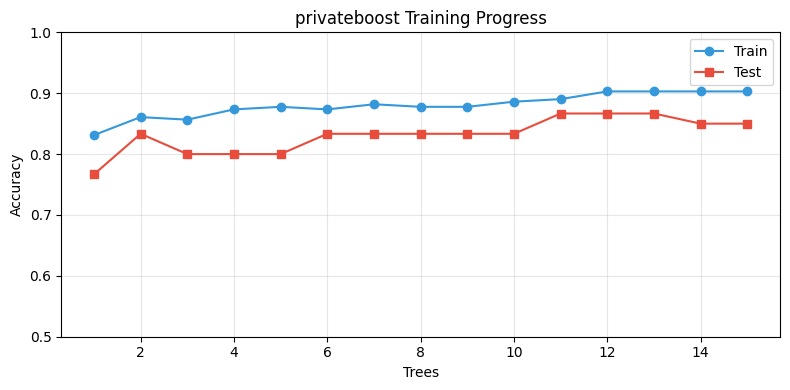


Final: Train=90.30%, Test=85.00%
Best test accuracy: 86.67%


In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_TREES+1), train_acc_history, "o-", label="Train", color="#3498db")
ax.plot(range(1, N_TREES+1), test_acc_history, "s-", label="Test", color="#e74c3c")
ax.set_xlabel("Trees")
ax.set_ylabel("Accuracy")
ax.set_title("privateboost Training Progress")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

print(f"\nFinal: Train={train_acc_history[-1]:.2%}, Test={test_acc_history[-1]:.2%}")
print(f"Best test accuracy: {max(test_acc_history):.2%}")

---
# Part 2: Split Quality Analysis

How much accuracy do we lose by finding splits from histogram-binned gradients instead of exact values?

We compare the **gain** achieved by:
- **Optimal**: Exhaustive search over all split points
- **privateboost**: Best split from 10-bin gradient histograms

In [18]:
# Use initial predictions for split analysis
predictions = np.full(len(y_train), initial_pred)

def compute_optimal_gain(X, y, preds, feat_idx, lambda_reg=1.0):
    """Find optimal split gain by exhaustive search."""
    g = preds - y
    h = np.ones_like(g)
    total_g, total_h = g.sum(), h.sum()
    base = (total_g ** 2) / (total_h + lambda_reg)
    
    idx = np.argsort(X[:, feat_idx])
    vals, gs, hs = X[idx, feat_idx], g[idx], h[idx]
    
    best = 0
    g_left, h_left = 0, 0
    for i in range(len(vals) - 1):
        g_left += gs[i]
        h_left += hs[i]
        if vals[i] == vals[i+1] or h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        gain = (g_left**2)/(h_left + lambda_reg) + ((total_g-g_left)**2)/((total_h-h_left) + lambda_reg) - base
        best = max(best, gain)
    return best

def compute_pb_gain(X, y, preds, feat_idx, bins, lambda_reg=1.0):
    """Find split gain using histogram binning."""
    g = preds - y
    h = np.ones_like(g)
    total_g, total_h = g.sum(), h.sum()
    base = (total_g ** 2) / (total_h + lambda_reg)
    
    bin_cfg = bins[feat_idx]
    n_bins = bin_cfg.n_bins + 2
    g_hist, h_hist = np.zeros(n_bins), np.zeros(n_bins)
    
    for i in range(len(X)):
        b = int(np.searchsorted(bin_cfg.edges, X[i, feat_idx], side="right")) - 1
        b = max(0, min(b, n_bins - 1))
        g_hist[b] += g[i]
        h_hist[b] += h[i]
    
    best = 0
    for i in range(n_bins - 1):
        g_left, h_left = g_hist[:i+1].sum(), h_hist[:i+1].sum()
        if h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        gain = (g_left**2)/(h_left + lambda_reg) + ((total_g-g_left)**2)/((total_h-h_left) + lambda_reg) - base
        best = max(best, gain)
    return best

# Compute for all features
results = []
for i, name in enumerate(FEATURES):
    opt = compute_optimal_gain(X_train, y_train, predictions, i, LAMBDA_REG)
    pb = compute_pb_gain(X_train, y_train, predictions, i, bins, LAMBDA_REG)
    ret = (pb / opt * 100) if opt > 0 else 100
    results.append({'feature': name, 'optimal': opt, 'privateboost': pb, 'retention': ret})

for r in results:
    print(f"{r['feature']:>10}: {r['retention']:5.1f}%")

print(f"\nMean retention: {np.mean([r['retention'] for r in results]):.1f}%")

       age: 100.0%
       sex: 100.0%
        cp: 100.0%
  trestbps:  93.6%
      chol:  99.7%
       fbs: 100.0%
   restecg: 100.0%
   thalach:  92.1%
     exang: 100.0%
   oldpeak:  90.2%
     slope: 100.0%
        ca: 100.0%
      thal: 100.0%

Mean retention: 98.1%


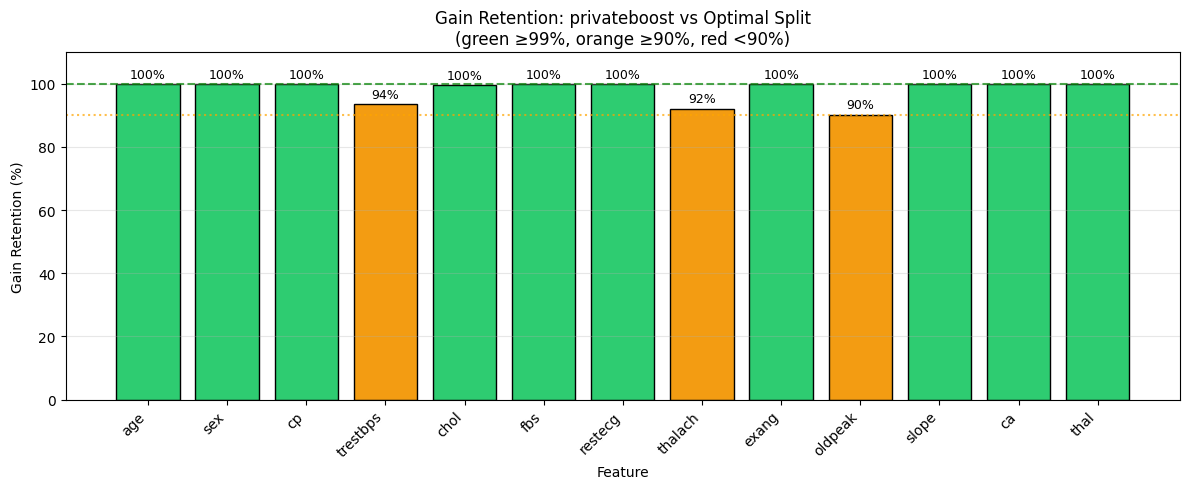

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

features = [r['feature'] for r in results]
retentions = [r['retention'] for r in results]
colors = ['#2ecc71' if r >= 99 else '#f39c12' if r >= 90 else '#e74c3c' for r in retentions]

bars = ax.bar(features, retentions, color=colors, edgecolor='black')
ax.axhline(100, color='green', linestyle='--', alpha=0.7)
ax.axhline(90, color='orange', linestyle=':', alpha=0.7)
ax.set_ylabel('Gain Retention (%)')
ax.set_xlabel('Feature')
ax.set_title('Gain Retention: privateboost vs Optimal Split\n(green ≥99%, orange ≥90%, red <90%)')
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

for bar, ret in zip(bars, retentions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{ret:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/figures/gain_retention.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 3: XGBoost Comparison

How does privateboost compare to the XGBoost library?

We compare:
- **privateboost**: Privacy-preserving federated training
- **XGBoost (matched)**: Same hyperparameters for fair comparison
- **XGBoost (default)**: Library defaults as practical baseline

In [20]:
# Use Breast Cancer dataset (larger)
data = load_breast_cancer()
indices = np.random.permutation(len(data.data))
split = int(len(data.data) * 0.8)

X_train_bc = data.data[indices[:split]]
y_train_bc = data.target[indices[:split]]
X_test_bc = data.data[indices[split:]]
y_test_bc = data.target[indices[split:]]

print(f"Breast Cancer: {len(X_train_bc)} train, {len(X_test_bc)} test, {data.data.shape[1]} features")

Breast Cancer: 455 train, 114 test, 30 features


In [21]:
def train_privateboost_metrics(X_train, y_train, X_test, y_test):
    """Train privateboost and return per-round metrics."""
    agg = Aggregator(n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS)
    shs = [ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS) for i in range(N_SHAREHOLDERS)]
    agg.set_shareholders(shs)
    clients = [Client(f"c_{i}", list(X_train[i]), float(y_train[i]), shs, threshold=THRESHOLD) for i in range(len(X_train))]
    
    for c in clients: c.submit_stats(round_id=0)
    b = agg.define_bins(round_id=0)
    init = float(agg.means[-1])
    for c in clients: c.prediction = init
    
    trees = []
    metrics = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    
    for tree_idx in range(N_TREES):
        agg.reset_tree()
        for c in clients: c.reset_node()
        splits, active = {}, [0]
        base_round_id = 1000 + tree_idx * 100
        
        for depth in range(MAX_DEPTH):
            round_id = base_round_id + depth
            for c in clients: c.submit_gradients(b, active, round_id=round_id, loss="squared")
            sp = agg.find_best_splits(round_id=round_id, active_nodes=active, lambda_reg=LAMBDA_REG, min_samples=5)
            if not sp: break
            splits.update(sp)
            for c in clients: c.apply_splits(sp)
            active = [id for s in sp.values() for id in [s.left_child_id, s.right_child_id]]
        
        leaf_ids = list(set(id for s in splits.values() for id in [s.left_child_id, s.right_child_id]) - set(splits.keys()))
        if 0 not in splits: leaf_ids.append(0)
        
        leaf_round_id = base_round_id + MAX_DEPTH
        for c in clients: c.submit_gradients(b, leaf_ids, round_id=leaf_round_id, loss="squared")
        leaves = agg.compute_leaf_values(round_id=leaf_round_id, leaf_nodes=leaf_ids, lambda_reg=LAMBDA_REG)
        for c in clients: c.update_prediction(leaves, LEARNING_RATE)
        trees.append((splits, leaves))
        
        # Clear shareholder data
        for sh in shs:
            for rid in range(base_round_id, base_round_id + MAX_DEPTH + 2):
                sh.clear_round(rid)
        
        # Metrics
        tr_p = np.array([c.prediction for c in clients])
        te_p = np.full(len(X_test), init)
        for i in range(len(X_test)):
            for sp, lv in trees:
                n = 0
                while n in sp:
                    n = sp[n].left_child_id if X_test[i, sp[n].feature_idx] <= sp[n].threshold else sp[n].right_child_id
                if n in lv: te_p[i] += LEARNING_RATE * lv[n].value
        
        metrics['train_acc'].append(accuracy_score(y_train, (tr_p >= 0.5).astype(int)))
        metrics['test_acc'].append(accuracy_score(y_test, (te_p >= 0.5).astype(int)))
        metrics['train_loss'].append(log_loss(y_train, np.clip(tr_p, 1e-7, 1-1e-7)))
        metrics['test_loss'].append(log_loss(y_test, np.clip(te_p, 1e-7, 1-1e-7)))
    
    return metrics

def train_xgboost_metrics(X_train, y_train, X_test, y_test, matched=True):
    """Train XGBoost and return per-round metrics."""
    metrics = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    for n in range(1, N_TREES + 1):
        params = dict(n_estimators=n, max_depth=MAX_DEPTH, learning_rate=LEARNING_RATE, 
                      reg_lambda=LAMBDA_REG, tree_method='hist', max_bin=N_BINS, random_state=42) if matched else dict(n_estimators=n, random_state=42)
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, verbose=False)
        
        metrics['train_acc'].append(accuracy_score(y_train, model.predict(X_train)))
        metrics['test_acc'].append(accuracy_score(y_test, model.predict(X_test)))
        metrics['train_loss'].append(log_loss(y_train, model.predict_proba(X_train)[:, 1]))
        metrics['test_loss'].append(log_loss(y_test, model.predict_proba(X_test)[:, 1]))
    return metrics

print("Training privateboost...")
pb_m = train_privateboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc)
print("Training XGBoost (matched)...")
xgb_matched = train_xgboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc, matched=True)
print("Training XGBoost (default)...")
xgb_default = train_xgboost_metrics(X_train_bc, y_train_bc, X_test_bc, y_test_bc, matched=False)
print("Done!")

Training privateboost...
Training XGBoost (matched)...
Training XGBoost (default)...
Done!


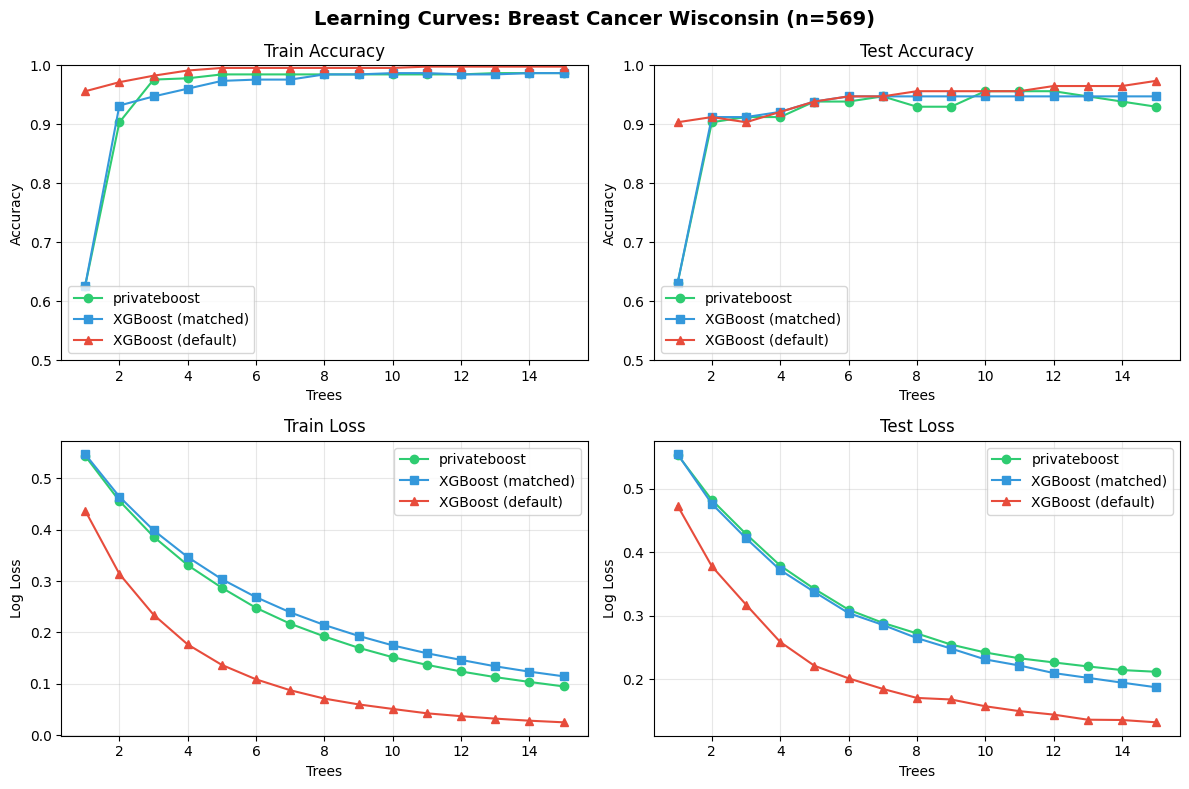


Final Test Accuracy:
  privateboost:      92.98%
  XGBoost (matched): 94.74%
  XGBoost (default): 97.37%


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
trees = range(1, N_TREES + 1)
colors = {'pb': '#2ecc71', 'matched': '#3498db', 'default': '#e74c3c'}

for ax, key, title, ylabel in [
    (axes[0,0], 'train_acc', 'Train Accuracy', 'Accuracy'),
    (axes[0,1], 'test_acc', 'Test Accuracy', 'Accuracy'),
    (axes[1,0], 'train_loss', 'Train Loss', 'Log Loss'),
    (axes[1,1], 'test_loss', 'Test Loss', 'Log Loss'),
]:
    ax.plot(trees, pb_m[key], 'o-', color=colors['pb'], label='privateboost')
    ax.plot(trees, xgb_matched[key], 's-', color=colors['matched'], label='XGBoost (matched)')
    ax.plot(trees, xgb_default[key], '^-', color=colors['default'], label='XGBoost (default)')
    ax.set_xlabel('Trees')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    if 'acc' in key: ax.set_ylim(0.5, 1.0)

fig.suptitle('Learning Curves: Breast Cancer Wisconsin (n=569)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Test Accuracy:")
print(f"  privateboost:      {pb_m['test_acc'][-1]:.2%}")
print(f"  XGBoost (matched): {xgb_matched['test_acc'][-1]:.2%}")
print(f"  XGBoost (default): {xgb_default['test_acc'][-1]:.2%}")

---
# Summary

**Key findings:**
- privateboost achieves **98% mean gain retention** compared to optimal splits (10 of 13 features at 100%)
- Test accuracy is **comparable to standard XGBoost** on both datasets
- **Individual data is never revealed** — only aggregate statistics leave each client

**Security properties (2-of-3 Shamir threshold):**
- Any single shareholder learns nothing about individual values
- Aggregator sees only aggregates, never raw values or client IDs
- Minimum 10 clients required to prevent individual isolation